In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/shivamb/netflix-shows/netflix_titles.csv


In [2]:
import os

for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

/kaggle/input/datasets/shivamb/netflix-shows/netflix_titles.csv


In [3]:
import pandas as pd
import sqlite3

# Step 1: Load data (IMPORTANT)
df = pd.read_csv('/kaggle/input/datasets/shivamb/netflix-shows/netflix_titles.csv')

# Step 2: Check data
print(df.head())

# Step 3: Create connection
conn = sqlite3.connect(':memory:')

# Step 4: Create table
df.to_sql('netflix', conn, index=False, if_exists='replace')

# Step 5: Test
pd.read_sql("SELECT COUNT(*) FROM netflix", conn)

  show_id     type                  title         director  \
0      s1    Movie   Dick Johnson Is Dead  Kirsten Johnson   
1      s2  TV Show          Blood & Water              NaN   
2      s3  TV Show              Ganglands  Julien Leclercq   
3      s4  TV Show  Jailbirds New Orleans              NaN   
4      s5  TV Show           Kota Factory              NaN   

                                                cast        country  \
0                                                NaN  United States   
1  Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...   South Africa   
2  Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...            NaN   
3                                                NaN            NaN   
4  Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...          India   

           date_added  release_year rating   duration  \
0  September 25, 2021          2020  PG-13     90 min   
1  September 24, 2021          2021  TV-MA  2 Seasons   
2  September 24, 2021        

,COUNT(*)
0,8807


In [4]:
pd.read_sql("SELECT COUNT(*) as total FROM netflix", conn)

,total
0,8807


In [5]:
pd.read_sql("""
SELECT type, COUNT(*) as total
FROM netflix
GROUP BY type
""", conn)

,type,total
0,Movie,6131
1,TV Show,2676


In [6]:
pd.read_sql("""
SELECT country, COUNT(*) as total
FROM netflix
GROUP BY country
ORDER BY total DESC
LIMIT 5
""", conn)

,country,total
0,United States,2818
1,India,972
2,None,831
3,United Kingdom,419
4,Japan,245


In [7]:
pd.read_sql("""
SELECT release_year, COUNT(*) as total
FROM netflix
GROUP BY release_year
ORDER BY release_year DESC
""", conn)

,release_year,total
0,2021,592
1,2020,953
2,2019,1030
3,2018,1147
4,2017,1032
...,...,...
69,1945,4
70,1944,3
71,1943,3
72,1942,2


In [8]:
pd.read_sql("""
SELECT rating, COUNT(*) as total
FROM netflix
GROUP BY rating
ORDER BY total DESC
""", conn)

,rating,total
0,TV-MA,3207
1,TV-14,2160
2,TV-PG,863
3,R,799
4,PG-13,490
5,TV-Y7,334
6,TV-Y,307
7,PG,287
8,TV-G,220
9,NR,80


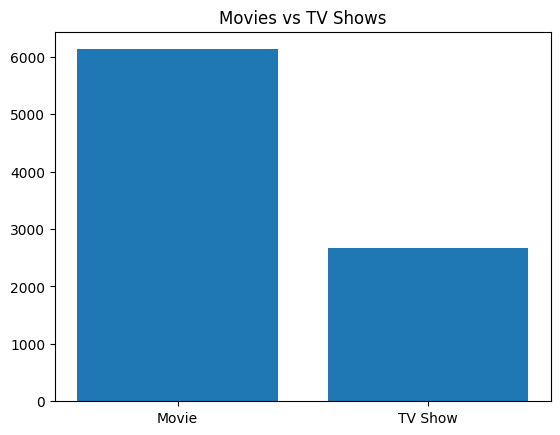

In [9]:
import matplotlib.pyplot as plt

data = pd.read_sql("""
SELECT type, COUNT(*) as total
FROM netflix
GROUP BY type
""", conn)

plt.bar(data['type'], data['total'])
plt.title("Movies vs TV Shows")
plt.show()